# Super-resolução de depth maps 8×8 → 32×32

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile
import torch
import torch.nn as nn
import yaml
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
BATCH_SIZE = 32
EPOCHS = 200
LEARNING_RATE = 1e-4
EARLY_STOPPING_PATIENCE = 20
ACCURACY_TOLERANCE_MM = 50

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)

print("Device:", DEVICE)

Device: cuda


## Modelo

Para trocar o modelo, substitua esta célula por qualquer `nn.Module` que receba `[B, 1, 8, 8]` e devolva `[B, 1, 32, 32]`, com profundidade normalizada em `[0, 1]`. Cada modelo grava seus resultados em `runs/<nome da classe>/`.

Padrão: QuickSRNet Small ([arXiv:2301.05723](https://arxiv.org/abs/2301.05723)), com 1 canal.

In [2]:
class QuickSRNetSmall(nn.Module):
    def __init__(self, scale=4, channels=32, intermediate_layers=2):
        super().__init__()
        layers = [nn.Conv2d(1, channels, 3, padding=1), nn.Hardtanh(0.0, 1.0)]
        for _ in range(intermediate_layers):
            layers += [nn.Conv2d(channels, channels, 3, padding=1), nn.Hardtanh(0.0, 1.0)]
        self.cnn = nn.Sequential(*layers)
        self.conv_last = nn.Conv2d(channels, scale**2, 3, padding=1)
        self.clip_output = nn.Hardtanh(0.0, 1.0)
        self.pixel_shuffle = nn.PixelShuffle(scale)
        self.initialize()

    # Inicialização quase-identidade do QuickSRNet: a rede começa próxima de um upsampling nearest-neighbor.
    @torch.no_grad()
    def initialize(self):
        for conv in self.cnn:
            if isinstance(conv, nn.Conv2d):
                for i in range(min(conv.in_channels, conv.out_channels)):
                    conv.weight[i, i, 1, 1] += 1.0
        self.conv_last.weight[:, 0, 1, 1] += 1.0

    def forward(self, x):
        return self.pixel_shuffle(self.clip_output(self.conv_last(self.cnn(x))))


model = QuickSRNetSmall().to(DEVICE)

output_shape = tuple(model(torch.zeros(1, 1, 8, 8, device=DEVICE)).shape)
assert output_shape == (1, 1, 32, 32), f"Saída {output_shape}, esperado (1, 1, 32, 32)"
print(f"{type(model).__name__}: {sum(p.numel() for p in model.parameters()):,} parâmetros")

QuickSRNetSmall: 23,440 parâmetros


## Dados

In [3]:
cwd = Path.cwd().resolve()

REPO_ROOT = next(
    (path for path in [cwd, *cwd.parents] if (path / "synthetic-dataset").is_dir()),
    None,
)

if REPO_ROOT is None:
    raise FileNotFoundError(f"Pasta synthetic-dataset/ não encontrada em {cwd} nem em seus diretórios pais")

DATASET_ROOT = REPO_ROOT / "synthetic-dataset" / "out" / "synthetic_depth_dataset"
RUNS_DIR = REPO_ROOT / "synthetic-dataset" / "train_model" / "runs"

with (DATASET_ROOT / "config" / "config_sensor.yaml").open(encoding="utf-8") as f:
    DEPTH_MAX_MM = float(yaml.safe_load(f)["sensor"]["max_range_m"]) * 1000.0

scene_dirs = sorted((DATASET_ROOT / "scenes").glob("scene_*"))

records = []
for scene_dir in scene_dirs:
    meta = yaml.safe_load((scene_dir / "metadata.yaml").read_text(encoding="utf-8"))
    records.append({
        "scene": scene_dir.name,
        "silo": meta["silo"]["model"],
        "surface_id": meta["surface"]["id"],
        "surface_type": meta["surface"]["type"],
    })
scenes_df = pd.DataFrame(records)


def load_depth(filename):
    depth_mm = np.stack([tifffile.imread(scene_dir / filename) for scene_dir in scene_dirs]).astype(np.float32)
    return torch.from_numpy(np.clip(depth_mm / DEPTH_MAX_MM, 0.0, 1.0)).unsqueeze(1)


depth_8x8 = load_depth("depth_8x8.tif")
depth_32x32 = load_depth("depth_32x32.tif")

indices = np.random.default_rng(SEED).permutation(len(scene_dirs))
n_train, n_val = int(len(indices) * 0.8), int(len(indices) * 0.1)
train_idx, val_idx, test_idx = np.split(indices, [n_train, n_train + n_val])

scenes_df["split"] = "train"
scenes_df.loc[val_idx, "split"] = "val"
scenes_df.loc[test_idx, "split"] = "test"

train_loader = DataLoader(
    TensorDataset(depth_8x8[train_idx], depth_32x32[train_idx]),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

print(f"Cenas: {len(scene_dirs)} | treino {len(train_idx)} | validação {len(val_idx)} | teste {len(test_idx)}")
print(f"DEPTH_MAX_MM = {DEPTH_MAX_MM:.0f} mm")

Cenas: 1879 | treino 1503 | validação 187 | teste 189
DEPTH_MAX_MM = 11000 mm


## Treinamento

In [4]:
def masked_l1(pred, target):
    # 0 no ground truth é "sem retorno" do sensor, não uma distância: fica fora da loss e das métricas.
    valid = target > 0
    return (pred[valid] - target[valid]).abs().mean()


def masked_abs_error_sum_mm(pred, target):
    valid = target > 0
    return (pred[valid] - target[valid]).abs().sum().item() * DEPTH_MAX_MM, valid.sum().item()


def depth_metrics(pred, target):
    valid = target > 0
    pred, target = pred[valid], target[valid]
    error = (pred - target) * DEPTH_MAX_MM
    abs_error = error.abs()
    rmse = error.pow(2).mean().sqrt()
    ratio = torch.maximum(pred / target, target / pred)
    return {
        "within_tolerance_pct": (abs_error <= ACCURACY_TOLERANCE_MM).float().mean().item() * 100,
        "mae_mm": abs_error.mean().item(),
        "rmse_mm": rmse.item(),
        "bias_mm": error.mean().item(),
        "median_absolute_error_mm": abs_error.median().item(),
        "p90_absolute_error_mm": abs_error.quantile(0.90).item(),
        "p95_absolute_error_mm": abs_error.quantile(0.95).item(),
        "psnr_db": (20 * torch.log10(DEPTH_MAX_MM / rmse.clamp(min=1e-9))).item(),
        "abs_rel_pct": ((pred - target).abs() / target).mean().item() * 100,
        "delta_1_pct": (ratio < 1.25).float().mean().item() * 100,
        "delta_2_pct": (ratio < 1.25**2).float().mean().item() * 100,
        "delta_3_pct": (ratio < 1.25**3).float().mean().item() * 100,
    }


def summarize_errors(pixels, by):
    return (
        pixels.groupby(by, observed=True)["error_mm"]
        .agg(
            valid_pixels="size",
            mae_mm=lambda error: error.abs().mean(),
            rmse_mm=lambda error: np.sqrt((error**2).mean()),
            bias_mm="mean",
            within_tolerance_pct=lambda error: (error.abs() <= ACCURACY_TOLERANCE_MM).mean() * 100,
        )
        .reset_index()
    )


@torch.no_grad()
def predict(depth_maps):
    model.eval()
    return torch.cat([model(batch.to(DEVICE)).cpu() for batch in depth_maps.split(1024)])

In [5]:
RUN_DIR = RUNS_DIR / type(model).__name__
RUN_DIR.mkdir(parents=True, exist_ok=True)

scenes_df.to_csv(RUN_DIR / "dataset_split.csv", index=False)
(RUN_DIR / "config.json").write_text(json.dumps({
    "model": type(model).__name__,
    "parameters": sum(p.numel() for p in model.parameters()),
    "seed": SEED,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "tolerance_mm": ACCURACY_TOLERANCE_MM,
    "depth_max_mm": DEPTH_MAX_MM,
}, indent=2))

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=8)

history = []
best_val_mae = float("inf")
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_abs_error_mm = 0.0
    total_valid_pixels = 0

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        pred = model(x)
        loss = masked_l1(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        abs_error_mm, valid_pixels = masked_abs_error_sum_mm(pred.detach(), y)
        total_abs_error_mm += abs_error_mm
        total_valid_pixels += valid_pixels

    val = depth_metrics(predict(depth_8x8[val_idx]), depth_32x32[val_idx])
    history.append({
        "epoch": epoch,
        "train_mae_mm": total_abs_error_mm / total_valid_pixels,
        "val_mae_mm": val["mae_mm"],
        "val_within_tolerance_pct": val["within_tolerance_pct"],
        "learning_rate": optimizer.param_groups[0]["lr"],
    })
    scheduler.step(val["mae_mm"])

    print(
        f"Época {epoch:02d} | MAE treino {history[-1]['train_mae_mm']:.1f} mm | "
        f"MAE validação {val['mae_mm']:.1f} mm | "
        f"validação com erro ≤ {ACCURACY_TOLERANCE_MM} mm: {val['within_tolerance_pct']:.1f}%"
    )

    if val["mae_mm"] < best_val_mae:
        best_val_mae = val["mae_mm"]
        epochs_without_improvement = 0
        torch.save(
            {"epoch": epoch, "model_state_dict": model.state_dict(), "val_metrics": val},
            RUN_DIR / "best_model.pt",
        )
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping na época {epoch}.")
            break

pd.DataFrame(history).round({"train_mae_mm": 1, "val_mae_mm": 1, "val_within_tolerance_pct": 1}).to_csv(
    RUN_DIR / "history.csv", index=False
)

Época 01 | MAE treino 1927.0 mm | MAE validação 739.2 mm | validação com erro ≤ 50 mm: 4.7%
Época 02 | MAE treino 560.8 mm | MAE validação 435.9 mm | validação com erro ≤ 50 mm: 8.1%
Época 03 | MAE treino 362.8 mm | MAE validação 306.8 mm | validação com erro ≤ 50 mm: 13.3%
Época 04 | MAE treino 262.7 mm | MAE validação 231.3 mm | validação com erro ≤ 50 mm: 18.1%
Época 05 | MAE treino 198.1 mm | MAE validação 180.4 mm | validação com erro ≤ 50 mm: 24.5%
Época 06 | MAE treino 156.2 mm | MAE validação 146.1 mm | validação com erro ≤ 50 mm: 34.0%
Época 07 | MAE treino 130.2 mm | MAE validação 124.1 mm | validação com erro ≤ 50 mm: 41.5%
Época 08 | MAE treino 114.5 mm | MAE validação 111.5 mm | validação com erro ≤ 50 mm: 48.0%
Época 09 | MAE treino 104.2 mm | MAE validação 101.9 mm | validação com erro ≤ 50 mm: 52.8%
Época 10 | MAE treino 96.5 mm | MAE validação 95.1 mm | validação com erro ≤ 50 mm: 55.1%
Época 11 | MAE treino 89.9 mm | MAE validação 89.2 mm | validação com erro ≤ 50 mm:

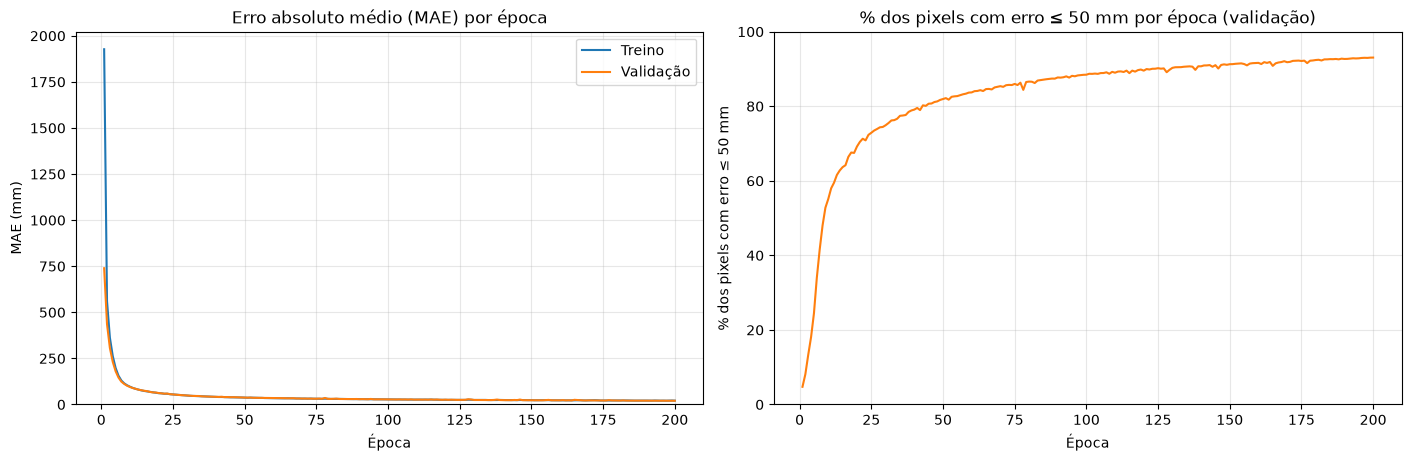

In [6]:
curves = pd.DataFrame(history)

fig, (ax_mae, ax_within) = plt.subplots(1, 2, figsize=(14, 4.5), layout="constrained")

ax_mae.plot(curves["epoch"], curves["train_mae_mm"], label="Treino")
ax_mae.plot(curves["epoch"], curves["val_mae_mm"], label="Validação")
ax_mae.set(ylim=(0, None), xlabel="Época", ylabel="MAE (mm)", title="Erro absoluto médio (MAE) por época")
ax_mae.legend()

ax_within.plot(curves["epoch"], curves["val_within_tolerance_pct"], color="C1")
ax_within.set(
    ylim=(0, 100),
    xlabel="Época",
    ylabel=f"% dos pixels com erro ≤ {ACCURACY_TOLERANCE_MM} mm",
    title=f"% dos pixels com erro ≤ {ACCURACY_TOLERANCE_MM} mm por época (validação)",
)

for ax in (ax_mae, ax_within):
    ax.grid(alpha=0.3)

fig.savefig(RUN_DIR / "training_curves.png", dpi=120)
plt.show()

## Teste

In [7]:
checkpoint = torch.load(RUN_DIR / "best_model.pt", map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])

pred_test = predict(depth_8x8[test_idx])
true_test = depth_32x32[test_idx]

test_metrics = depth_metrics(pred_test, true_test)
(RUN_DIR / "test_metrics.json").write_text(
    json.dumps({name: round(value, 2) for name, value in test_metrics.items()}, indent=2)
)

valid = true_test > 0
# true_test[valid] lista os pixels cena a cena, na ordem de test_idx.
pixels = scenes_df.loc[np.repeat(test_idx, valid.sum(dim=(1, 2, 3)).numpy()), ["scene", "silo", "surface_type"]]
pixels = pixels.reset_index(drop=True)
pixels["true_mm"] = true_test[valid].double().numpy() * DEPTH_MAX_MM
pixels["pred_mm"] = pred_test[valid].double().numpy() * DEPTH_MAX_MM
pixels["error_mm"] = pixels["pred_mm"] - pixels["true_mm"]

print(
    f"Época {checkpoint['epoch']} (menor MAE de validação): {test_metrics['within_tolerance_pct']:.1f}% dos pixels "
    f"com erro ≤ {ACCURACY_TOLERANCE_MM} mm | MAE {test_metrics['mae_mm']:.1f} mm"
)

Época 199 (menor MAE de validação): 92.7% dos pixels com erro ≤ 50 mm | MAE 21.1 mm


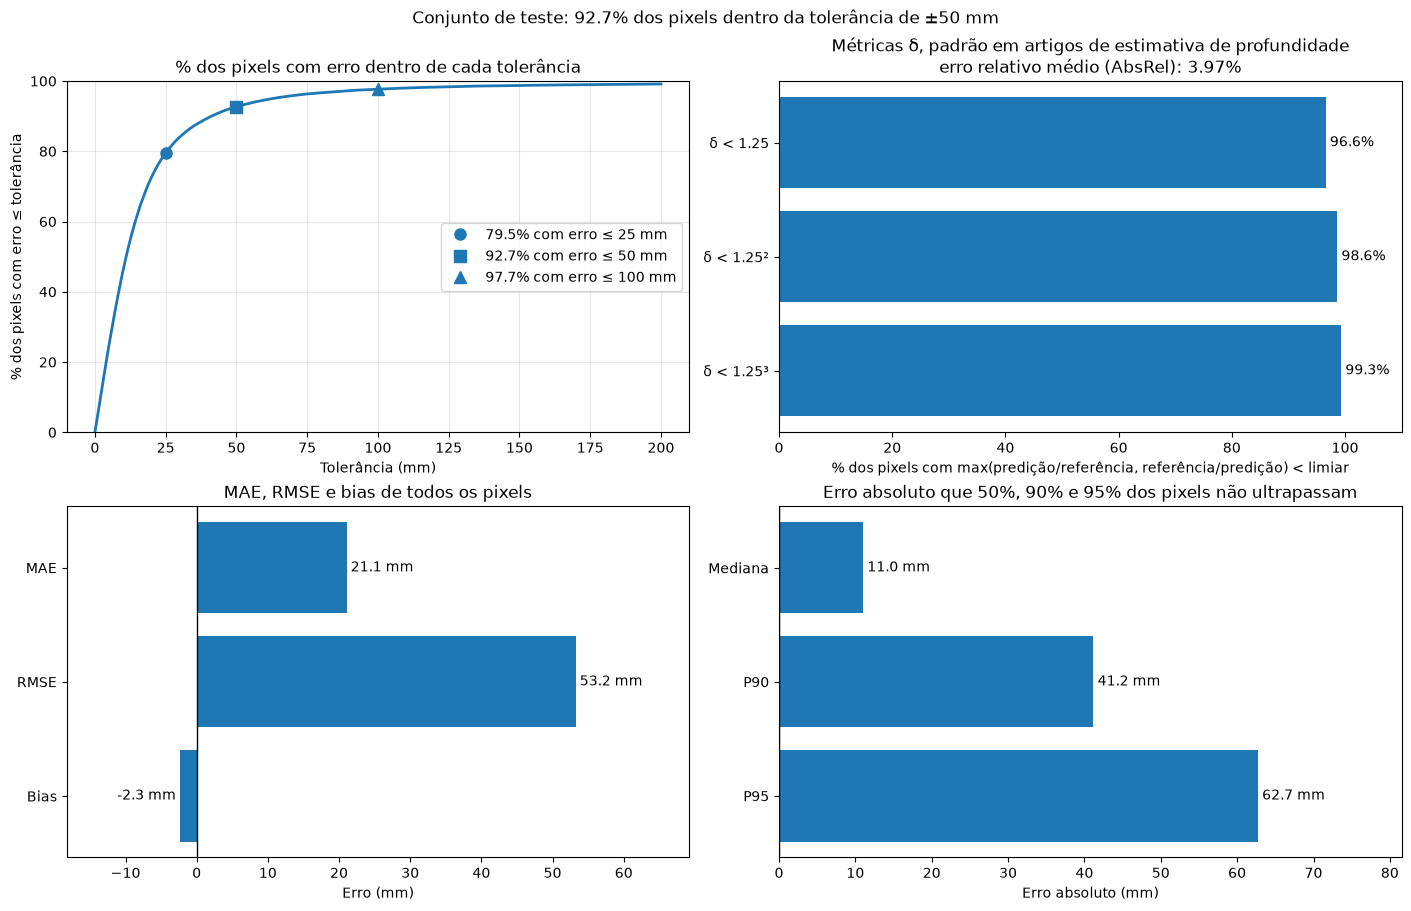

In [8]:
def plot_mm_bars(ax, values_mm, title, xlabel):
    values = list(values_mm.values())
    bars = ax.barh(list(values_mm), values)
    ax.bar_label(bars, fmt="%.1f mm", padding=3)
    ax.axvline(0, color="black", linewidth=1)
    span = max(abs(value) for value in values)
    left = min(values) - 0.3 * span if min(values) < 0 else 0
    ax.set(xlim=(left, max(values) + 0.3 * span), xlabel=xlabel, title=title)
    ax.invert_yaxis()


abs_error_mm = pixels["error_mm"].abs().to_numpy()
tolerances = np.arange(4 * ACCURACY_TOLERANCE_MM + 1)
within_by_tolerance = np.searchsorted(np.sort(abs_error_mm), tolerances, side="right") / len(abs_error_mm) * 100

fig, ((ax_curve, ax_delta), (ax_global, ax_spread)) = plt.subplots(2, 2, figsize=(14, 9), layout="constrained")

ax_curve.plot(tolerances, within_by_tolerance, linewidth=2)
for tolerance, marker in zip([ACCURACY_TOLERANCE_MM / 2, ACCURACY_TOLERANCE_MM, 2 * ACCURACY_TOLERANCE_MM], "os^"):
    within_pct = (abs_error_mm <= tolerance).mean() * 100
    ax_curve.plot(tolerance, within_pct, marker, color="C0", markersize=8, label=f"{within_pct:.1f}% com erro ≤ {tolerance:.0f} mm")
ax_curve.set(
    ylim=(0, 100),
    xlabel="Tolerância (mm)",
    ylabel="% dos pixels com erro ≤ tolerância",
    title="% dos pixels com erro dentro de cada tolerância",
)
ax_curve.legend(loc="center right")
ax_curve.grid(alpha=0.3)

bars = ax_delta.barh(
    ["δ < 1.25", "δ < 1.25²", "δ < 1.25³"],
    [test_metrics["delta_1_pct"], test_metrics["delta_2_pct"], test_metrics["delta_3_pct"]],
)
ax_delta.bar_label(bars, fmt="%.1f%%", padding=3)
ax_delta.invert_yaxis()
ax_delta.set(
    xlim=(0, 110),
    xticks=range(0, 101, 20),
    xlabel="% dos pixels com max(predição/referência, referência/predição) < limiar",
    title=f"Métricas δ, padrão em artigos de estimativa de profundidade\nerro relativo médio (AbsRel): {test_metrics['abs_rel_pct']:.2f}%",
)

plot_mm_bars(
    ax_global,
    {"MAE": test_metrics["mae_mm"], "RMSE": test_metrics["rmse_mm"], "Bias": test_metrics["bias_mm"]},
    "MAE, RMSE e bias de todos os pixels",
    "Erro (mm)",
)
plot_mm_bars(
    ax_spread,
    {
        "Mediana": test_metrics["median_absolute_error_mm"],
        "P90": test_metrics["p90_absolute_error_mm"],
        "P95": test_metrics["p95_absolute_error_mm"],
    },
    "Erro absoluto que 50%, 90% e 95% dos pixels não ultrapassam",
    "Erro absoluto (mm)",
)

fig.suptitle(
    f"Conjunto de teste: {test_metrics['within_tolerance_pct']:.1f}% dos pixels "
    f"dentro da tolerância de ±{ACCURACY_TOLERANCE_MM} mm"
)
fig.savefig(RUN_DIR / "test_metrics.png", dpi=120)
plt.show()

## Análise de erros no teste

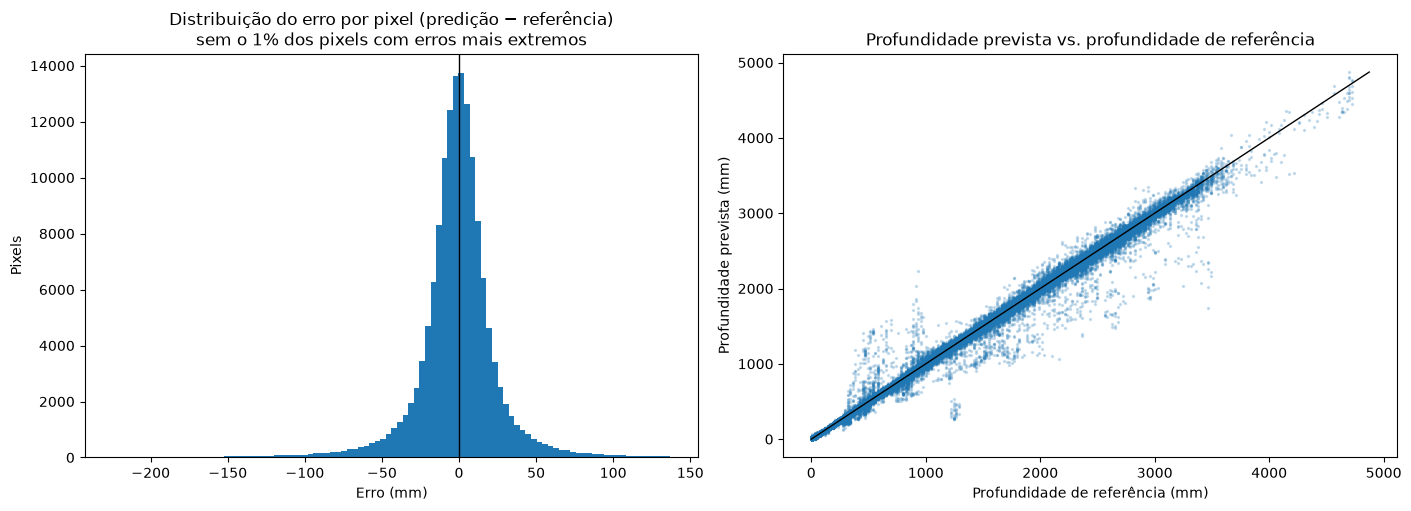

In [9]:
fig, (ax_hist, ax_scatter) = plt.subplots(1, 2, figsize=(14, 5), layout="constrained")

ax_hist.hist(pixels["error_mm"], bins=100, range=tuple(np.percentile(pixels["error_mm"], [0.5, 99.5])))
ax_hist.axvline(0, color="black", linewidth=1)
ax_hist.set(
    xlabel="Erro (mm)",
    ylabel="Pixels",
    title="Distribuição do erro por pixel (predição − referência)\nsem o 1% dos pixels com erros mais extremos",
)

depth_limit = max(pixels["true_mm"].max(), pixels["pred_mm"].max())
ax_scatter.scatter(pixels["true_mm"], pixels["pred_mm"], s=2, alpha=0.2, rasterized=True)
ax_scatter.plot([0, depth_limit], [0, depth_limit], color="black", linewidth=1)
ax_scatter.set(
    xlabel="Profundidade de referência (mm)",
    ylabel="Profundidade prevista (mm)",
    title="Profundidade prevista vs. profundidade de referência",
)

fig.savefig(RUN_DIR / "error_distribution.png", dpi=120)
plt.show()

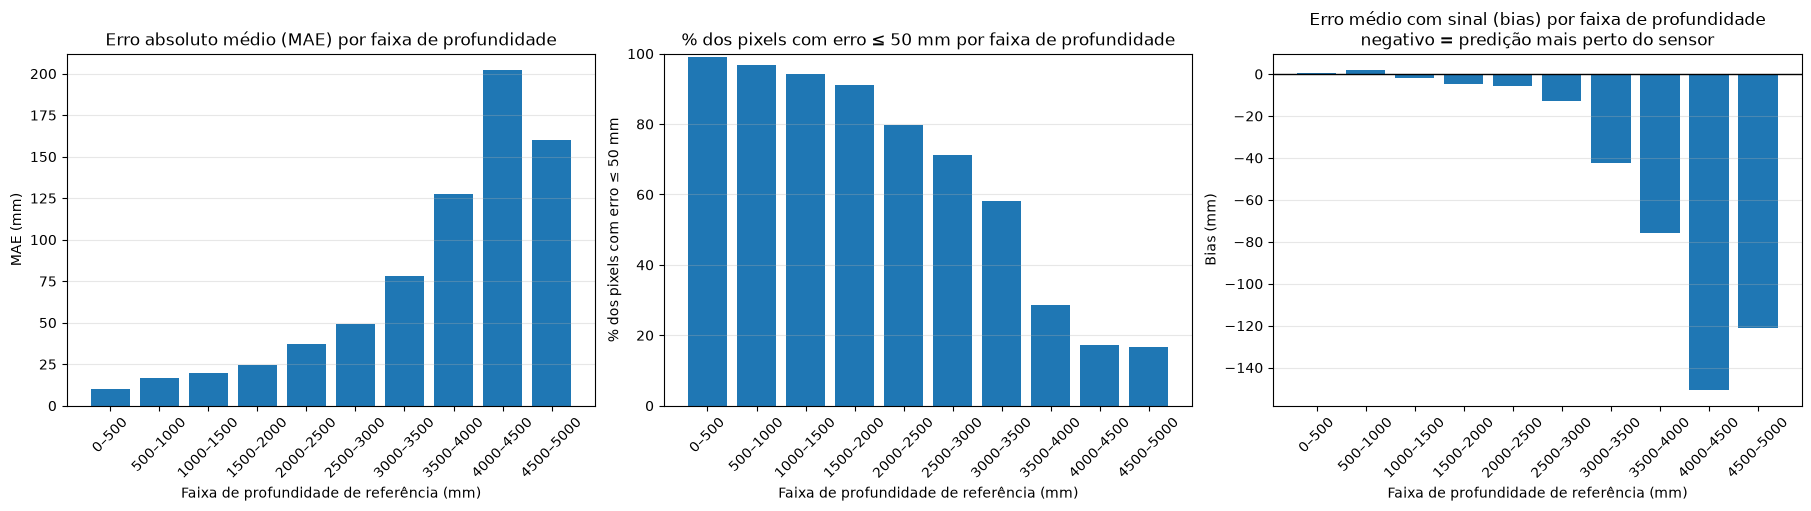

In [10]:
range_width_mm = 500
pixels["depth_range_start_mm"] = (pixels["true_mm"] // range_width_mm * range_width_mm).astype(int)
pixels["depth_range_mm"] = (
    pixels["depth_range_start_mm"].astype(str) + "–" + (pixels["depth_range_start_mm"] + range_width_mm).astype(str)
)

metrics_by_depth_range = summarize_errors(pixels, ["depth_range_start_mm", "depth_range_mm"])
metrics_by_depth_range = metrics_by_depth_range.drop(columns="depth_range_start_mm")
metrics_by_depth_range.round(2).to_csv(RUN_DIR / "metrics_by_depth_range.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), layout="constrained")

panels = [
    ("mae_mm", "Erro absoluto médio (MAE) por faixa de profundidade", "MAE (mm)"),
    ("within_tolerance_pct", f"% dos pixels com erro ≤ {ACCURACY_TOLERANCE_MM} mm por faixa de profundidade", f"% dos pixels com erro ≤ {ACCURACY_TOLERANCE_MM} mm"),
    ("bias_mm", "Erro médio com sinal (bias) por faixa de profundidade\nnegativo = predição mais perto do sensor", "Bias (mm)"),
]
for ax, (column, title, ylabel) in zip(axes, panels):
    ax.bar(metrics_by_depth_range["depth_range_mm"], metrics_by_depth_range[column])
    ax.set(xlabel="Faixa de profundidade de referência (mm)", ylabel=ylabel, title=title)
    ax.tick_params(axis="x", labelrotation=45)
    ax.grid(axis="y", alpha=0.3)

axes[1].set_ylim(0, 100)
axes[2].axhline(0, color="black", linewidth=1)

fig.savefig(RUN_DIR / "metrics_by_depth_range.png", dpi=120)
plt.show()

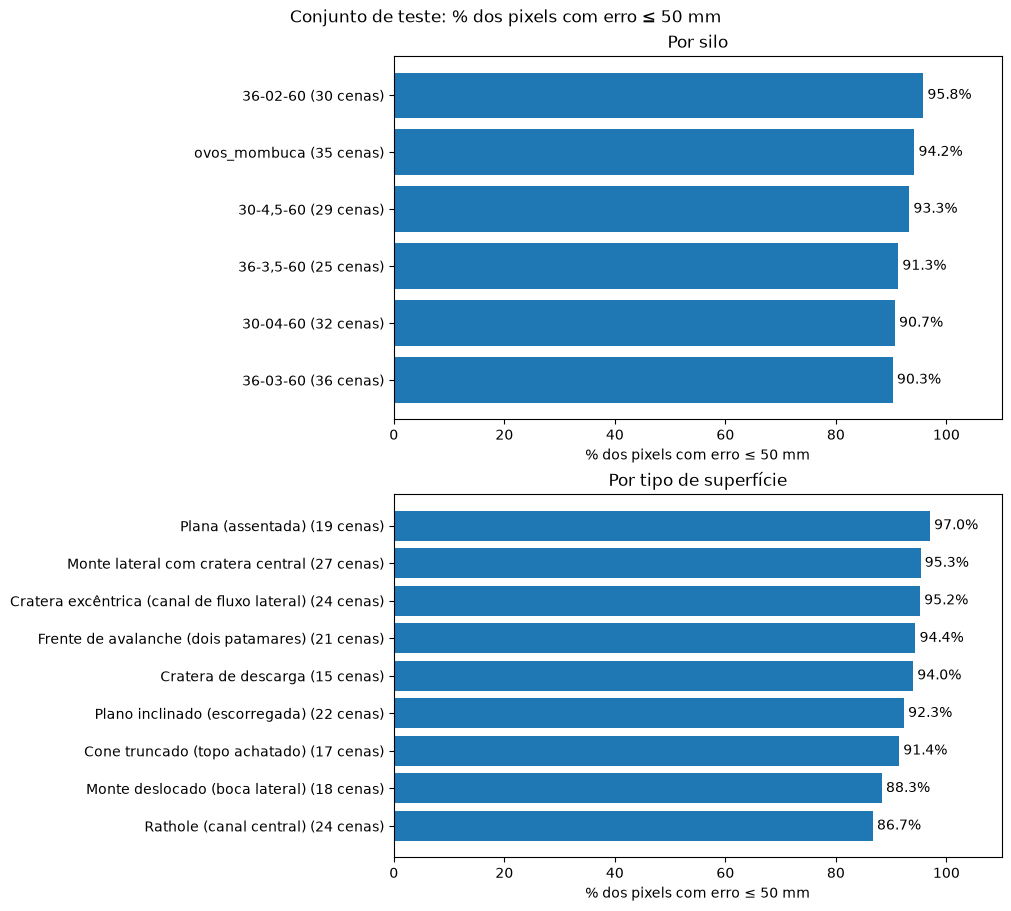

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(10, 9), layout="constrained")

for ax, group, title in zip(
    axes,
    ["silo", "surface_type"],
    ["Por silo", "Por tipo de superfície"],
):
    group_metrics = summarize_errors(pixels, group).sort_values("within_tolerance_pct")
    scene_counts = pixels.groupby(group)["scene"].nunique()
    bars = ax.barh(
        [f"{name} ({scene_counts[name]} cenas)" for name in group_metrics[group]],
        group_metrics["within_tolerance_pct"],
    )
    ax.bar_label(bars, fmt="%.1f%%", padding=3)
    ax.set(
        xlim=(0, 110),
        xticks=range(0, 101, 20),
        xlabel=f"% dos pixels com erro ≤ {ACCURACY_TOLERANCE_MM} mm",
        title=title,
    )

fig.suptitle(f"Conjunto de teste: % dos pixels com erro ≤ {ACCURACY_TOLERANCE_MM} mm")
fig.savefig(RUN_DIR / "performance_by_group.png", dpi=120)
plt.show()

In [12]:
metrics_by_scene = summarize_errors(pixels, ["scene", "silo", "surface_type"])
metrics_by_scene.round(2).to_csv(RUN_DIR / "metrics_by_scene.csv", index=False)

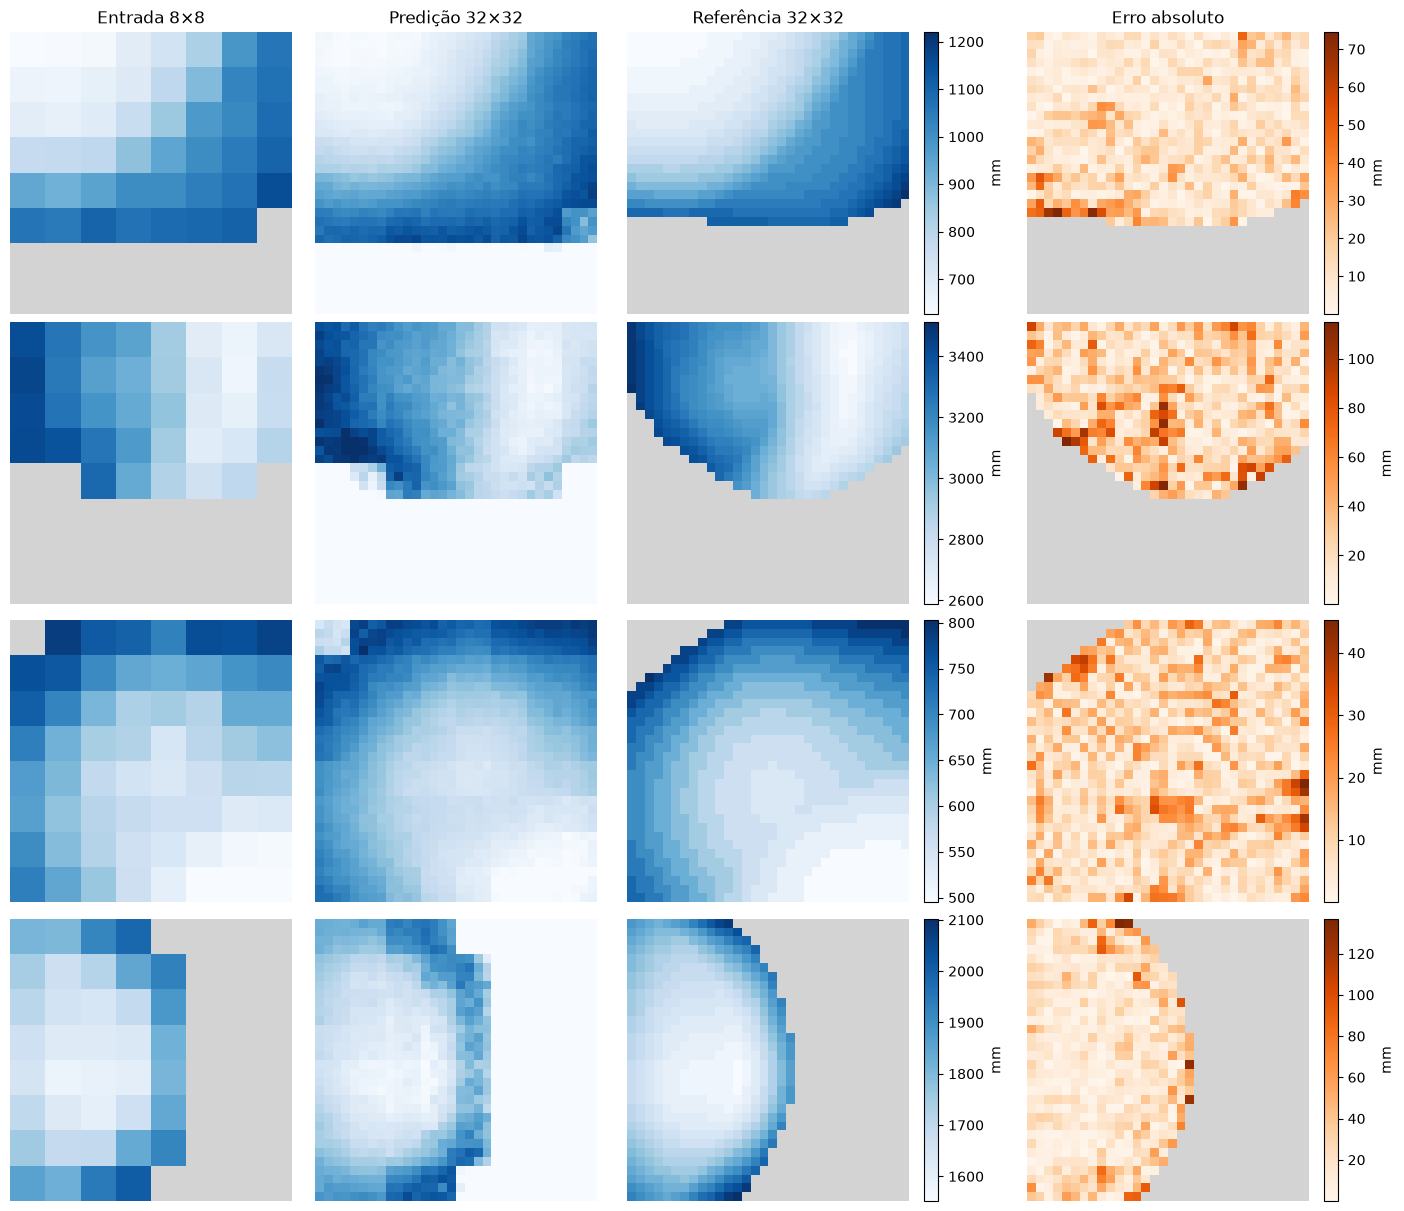

In [13]:
depth_cmap = plt.get_cmap("Blues").with_extremes(bad="lightgray")
error_cmap = plt.get_cmap("Oranges").with_extremes(bad="lightgray")

fig, axes = plt.subplots(4, 4, figsize=(14, 12), layout="constrained")

for row, i in zip(axes, range(4)):
    input_mm = depth_8x8[test_idx[i], 0].numpy() * DEPTH_MAX_MM
    pred_map_mm = pred_test[i, 0].numpy() * DEPTH_MAX_MM
    true_map_mm = true_test[i, 0].numpy() * DEPTH_MAX_MM
    depth_scale = dict(cmap=depth_cmap, vmin=true_map_mm[true_map_mm > 0].min(), vmax=true_map_mm.max())

    row[0].imshow(np.where(input_mm > 0, input_mm, np.nan), **depth_scale)
    row[1].imshow(pred_map_mm, **depth_scale)
    true_image = row[2].imshow(np.where(true_map_mm > 0, true_map_mm, np.nan), **depth_scale)
    error_image = row[3].imshow(np.where(true_map_mm > 0, np.abs(pred_map_mm - true_map_mm), np.nan), cmap=error_cmap)
    fig.colorbar(true_image, ax=row[2], label="mm")
    fig.colorbar(error_image, ax=row[3], label="mm")

for ax, title in zip(axes[0], ["Entrada 8×8", "Predição 32×32", "Referência 32×32", "Erro absoluto"]):
    ax.set_title(title)
for ax in axes.flat:
    ax.axis("off")

fig.savefig(RUN_DIR / "examples.png", dpi=120)
plt.show()